## TextMining
- 비정형 데이터(ex.텍스트)에서 의미(인사이트)를 추출하는 작업
- 자연어 처리 기술도 접목해서 최근 많이 수행되고 있음
  - 자연어 처리 : 사람의 언어(텍스트,음성)를 컴퓨터가 이해할 수 있도록 처리하는 일련의 과정

## TextMining process
1. 텍스트 수집
2. 정제(전처리)
3. 토큰화
4. 수치화
5. 분석 & 적용

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# 작업 디렉토리 변경
%cd /content/drive/MyDrive/TextMining

/content/drive/MyDrive/TextMining


### 데이터 수집 및 로딩
- https://github.com/smilegate-ai/korean_unsmile_dataset
- 스마일게이트의 한국어 혐오표현 데이터 셋을 활용

In [40]:
import pandas as pd

train = pd.read_csv('data/unsmile_train_v1.0.tsv', delimiter='\t')
test = pd.read_csv('data/unsmile_valid_v1.0.tsv', delimiter='\t')

In [41]:
display(train.head())
display(test.head())

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭
0,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,1,0
1,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,0,0
2,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,1,0
3,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,1,0
4,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,0,0


,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭
0,ㅇㄱㄹㅇ 진짜 죽어도 상관없다는 마인드로 싸웠더니 지금 서열 상타취노 식칼들고 니가...,0,1,0,0,0,0,0,0,0,0,0
1,여자들은 취미가 애낳는건가.. 취미를 좀 가져라,1,0,0,0,0,0,0,0,0,0,0
2,개슬람녀 다 필요없고 니 엄마만 있으면 된다,0,0,0,1,0,0,1,0,0,0,0
3,조팔ㅋㅋ 남한 길거리 돌아다니면 한국남자때문에 눈재기하는데 그걸 내 폰에 굳이 담아...,0,1,0,0,0,0,0,0,0,0,0
4,바지 내리다 한남들 와꾸 보고 올려뿟노,0,1,0,0,0,0,0,0,0,0,0


In [42]:
# 결측치 확인
print(train.isnull().sum(), test.isnull().sum())

문장       0
여성/가족    0
남성       0
성소수자     0
인종/국적    0
연령       0
지역       0
종교       0
기타 혐오    0
악플/욕설    0
clean    0
개인지칭     0
dtype: int64 문장       0
여성/가족    0
남성       0
성소수자     0
인종/국적    0
연령       0
지역       0
종교       0
기타 혐오    0
악플/욕설    0
clean    0
개인지칭     0
dtype: int64


## 2. 텍스트 분류
- 텍스트 마이닝 프로세스를 활용해보자!

### 정제(Cleaning)
- 불용어 제거 : 불필요한 단어(또는 토큰)를 제거하는 작업
- 어간 추출 : 단어의 핵심 부분(어간)만 추출
- 표준어화 : 표현 방법을 표준어에 맞춰서 변경

### 정규표현식(Regular Expression)
- 특정한 패턴(규칙)을 가진 문자열의 집합을 표현하는 언어
- 핸드폰번호나 이메일처럼 패턴이 있는 문자열의 검색과 치환을 위해 프로그래밍 언어에서 대부분 지원하고 있다.

In [43]:
import re # 정규표현식을 사용할 수 있는 모듈 로딩

In [44]:
# 전화번호 검출 예시

p = re.compile("010-?[0-9]{4}-?\\d{4}") # 휴대폰 번호 형식을 찾기 위한 정규 표현식

# '010-?[0-9]{4}-?\\d{4}' 패턴에 대한 설명 :
# '010' : 휴대폰 번호의 첫 세자리(010으로 시작)
# -? : 하이픈(-)이 있을 수도 있고 없을 수도 있음(선택적)
# '[0-9]{4}' : 0부터 9사이의 숫자가 정확히 4번 반복됨
# -? : 하이픈(-)이 있을 수도 있고 없을 수도 있음(선택적)
# '\\d{4}' : 숫자 4개(\\d는 숫자 하나를 의미, {4}는 4번 반복됨)
# 010-1234-5678 / 010-12345678 / 01012345678

In [45]:
p.search('전화번호 : 010-1234-5678')

<re.Match object; span=(7, 20), match='010-1234-5678'>

In [46]:
p.search('전화번호 : 010-123-5678')

## 혐오표현 데이터 클렌징
- ㅋㅋㅋㅋ,ㅎㅎㅎ,ㄷㄷㄷ,ㅇㅇ 같이 정해진 횟수 없이 반복되는 글자 삭제 -> 정규표현식

In [47]:
# 패턴생성
p = re.compile('[ㅋㅎㄷㅇ~!?.\\-ㅡ0-9a-z]+')

# 정규 표현식 패턴 설명 :
# '[...]' : 대괄호 내부에 포함된 문자 중 하나와 일치하는 문자들을 의미
# 'ㅋㅎㄷㅇ' : 'ㅋ','ㅎ','ㄷ','ㅇ' 중 하나의 문자가 들어간 부분을 매칭
# 한국어에서 자주 쓰이는 인터넷 표현 : ㅋㅋ,ㅎㅎ,ㄷㄷ,ㅇㅇ
# '~!?.\\-' : 틸트(~),느낌표(!),물음표(?),마침표(.),하이픈(-) 중 하나와 일치
#             여기서 '\\'는 이스케이프 문자로, '\-'을 문자 그대로 인식하도록 처리
# 'ㅡ' : 한글 모음 'ㅡ'를 포함
# '0-9' : 0부터 9까지의 숫자 중 하나와 일치
# 'a-z' : 소문자 알파벳(a부터 z까지) 중 하나와 일치
# '+' : 해당 문자 집합이 한번 이상 반복될 수 있음을 의미

In [48]:
train_clean = [] # 전처리된 전체 텍스트를 담을 리스트

for doc in train['문장']:
  temp = [] # 전처리된 문장의 토큰들이 들어갈 리스트
  for token in doc.split(' '): # 한개의 문장을 토큰화하여 반복
    if len(token) < 2 : # 1 글자 제거
      continue
    if p.search(token) : # 정규표현식 패턴에 매칭되는지 확인
      continue
    temp.append(token)
  train_clean.append(' '.join(temp)) # 정상적인 토큰을 전체리스트에 추가

In [49]:
train_clean

['일안하는 시간은 쉬고싶어서 그런게 아닐까',
 '아동성범죄와 페도버는 기록바 끊어져 영원히 고통 무슬림 IQ 떨어지고 출산 위험은',
 '루나 솔로앨범 나왔을 때부터 머모 기운 있었음 진짜 띵곡임 들어보셈"',
 '홍팍에도 어버이연합인가 보내요 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽에서 고소',
 '아놔 여기 댓들은 여자들이 김치녀라고 먼저 여자들은 심하게 이렇게 내가 둘다 나쁜 이상도 이하도 아닌데',
 '고향가서 피방가면 동네 부럴 친구들이랑은 거르는 없이 이야기하니까 말하게 되더라 당연히 키보드를 치거나 그러지는 않는데 말하는게 많이 거칠어지긴 반성해야겠네',
 '예수 십새끼 개새끼 창녀아들 애비실종 가정교육 못받은 무뇌충 허언증 정신병자 사기꾼 망상 근본없는 병신 장애인 짱개 흑인 이슬람 전라도랑 동급',
 '나이쳐먹고 피시방가는 놈들은 대가리에 똥만찬 놈들임',
 '출산청같은 우리나라 계집들 의무적으로 군대보내면 해결될 정신개조부터 지할꺼 다하고 무슨 애를 낳고 무슨 자식교육을',
 '재능 ㅂㅅㅌㅊ노 합성배우고싶다이기',
 '가짜 남자는 어떻게',
 '이슬람뺨치내',
 '어린이집에 월요일에 데려다주고 금요일에 데리고 가슴이 너무 아가가 얼마나',
 '갓슬람 정희구현 테러 ㅅㅅㅅㅅ미제양키새끼들에게는 테러가 답이다좆같은 양키 씨발새끼들',
 'AICPA 따고 넘어갔나보네',
 '리더십, 메시지로 내부 결속을 강화하고 외부로 이미지를 구축하여 다시 교회로 모일수 있기를 소망하고 기도합니다',
 '협박스킬은 패시브랑께',
 '위로와 격려를 호텔에서 저여자도 정상은 아니구만 완전 지네 할아버지보다 나이가 많을듯한데 둘다 그렇게 더러운짓은 하고 설교를 어떻게',
 '메틸 알콜 집에서 쓰고 질문 에틸에 메틸 공업용 에틸 알콜은 면세라 불법적으로 술제조 때문에 정도 메틸이 들어가면서 제조방지용으로',
 '띄울사람이 진짜 없긴 없나보다',
 '한국패미=고유정 수준',
 'CNN 구구절절 팩트',
 '빼고 아무것도 없는 개돼지 정권이노 탄핵 개힘조',
 

In [50]:
test_clean = [] # 전처리된 전체 텍스트를 담을 리스트

for doc in test['문장']:
  temp = [] # 전처리된 문장의 토큰들이 들어갈 리스트
  for token in doc.split(' '): # 한개의 문장을 토큰화하여 반복
    if len(token) < 2 : # 1 글자 제거
      continue
    if p.search(token) : # 정규표현식 패턴에 매칭되는지 확인
      continue
    temp.append(token)
  test_clean.append(' '.join(temp)) # 정상적인 토큰을 전체리스트에 추가

In [51]:
test_clean

['진짜 죽어도 상관없다는 마인드로 싸웠더니 지금 서열 상타취노 식칼들고 니가 안찌르면 내가 찌른다 했더니 애비충 냄동충 알아서기노 ^됫^ 한번 서열 잡고 담에 개길때마다 세게나가면 확실하게 짓누를수있다익이',
 '여자들은 취미가 취미를 가져라',
 '개슬람녀 필요없고 엄마만 있으면 된다',
 '남한 길거리 돌아다니면 한국남자때문에 눈재기하는데 그걸 폰에 굳이 담아야하노',
 '바지 내리다 한남들 와꾸 보고 올려뿟노',
 '저새끼 슈스케나온새끼잖아',
 '모든 이슬람이 테러리스트는 아니지만 모든 테러리스트는 자유민주국가에서 테러분자 감시는 텄고요, 막는게 최선',
 '역시 (절레절레)',
 '그만해라 틀딱새끼들 달려와서 좆족으로 몰아간다 이제',
 '잘생긴 형같음절대로 여자로 안보임',
 '여성혐오도 아니고 상식 비상식의 저게 한국사회의 약이되는거지 독이 될거라고 생각하는건 대가리좀 깨라',
 '오히려 태평양 패권을 두고 싸운 일본넘들이 두렵게 느껴지는게 정상인데',
 '전라도 통수쩌는 위선자들',
 '두번째는 펨섭이라그래',
 '민주화보소',
 '동성애로 인해 에이즈질환이 급증했는데 본인한테도 피해 타인한테도 동성애는 분명한 죄, 회개하지 않으면 멸망한다고 하나님이',
 '림종석 림수경 수상하지',
 '팩트라 반박은 하고 부들대는 김치좆 답노',
 '저런 불만이 있을테니 외국인들 자동가입 안되게해서 보험료 적용 못받게 해야지 그래야 감기나 배탈로 병원갔다가 병원비랑 약값 보고 식겁해 공단 뛰어가 가입시켜달라고',
 '재크 나이프 하니까 진중곤이 생각나네요',
 '으이고,,누가 그러케 걸래같이 놀리렛나요 남자는 이래서 조신헤야함니다',
 '유튜브 캡쳐 팩트이게 일베저장소 수준',
 '똥남아 다운화 다추방해라 진짜 자지새끼들 딸딸이나치지 없는형편에 아무구멍에라도 박아보겠다고 똥남아새끼들 수입해와서 박아대고 좆같네진짜 씹새끼들',
 '야이 점쟁이새끼야 더러운글 그만올리고점사나 잘봐라',
 '친구먹자 아무것도 하지 않고 썩은 고기나 찾는 하이에나 부대나 인정해라, 

In [52]:
# r'' : 원시(raw)문자열, \를 하나만 사용 가능하게끔 만듬!
pattern = r'[^a-zA-Z0-9가-힣\s\.\?\!]'

#즉, 이 패턴은 다음을 제외한 것만 찾습니다:
# a-z, A-Z: 영문 소문자, 대문자
# 0-9: 숫자
# 가-힣: 한글
# \s: 공백 문자 (띄어쓰기, 탭, 줄바꿈 등)
# \.: 마침표 .
# \?: 물음표 ?
# \!: 느낌표 !
# [^...] 안에 포함된 문자 "이외의" 것을 의미합니다.
# 정상문자가아닌 특수문자,이모지,한자, 기타 이상한 기호를 찾기 위해 사용

# sub : 치환하는 함수
re.sub(pattern,'','안녕하세요 ㅋㅋㅋㅋㅋ')
# 위 패턴이 아닌 경우(^) ''(공백)으로 반환

'안녕하세요 '

### 형태소분석
- Konlpy
- 한국어 : konlpy(Okt,Kkma,Komoran 등)
- 영어 : NLTK 등

| 분석기    | 속도        | 정확도        | 특징                                                         | 장단점                                                         |
|-----------|-------------|---------------|--------------------------------------------------------------|----------------------------------------------------------------|
| **Mecab** | 매우 빠름   | 높음          | - 백터 기반의 빠른 분석<br>- 대용량 데이터 처리에 적합          | + **장점:** 속도 및 효율성 우수<br>- **단점:** 설치가 다소 복잡, 사전 관리 필요 |
| **Kkma**  | 느림        | 높음          | - 문장 단위의 세밀한 분석 제공<br>- 다양한 형태소 정보 리턴       | + **장점:** 상세 분석, 문맥 파악 용이<br>- **단점:** 속도 느림, 대용량 데이터에 부적합 |
| **Hannanum** | 보통     | 중간          | - KAIST 개발 분석기로 전통적 접근법 사용<br>- 기본 문법 규칙 기반  | + **장점:** 비교적 안정적인 결과 제공<br>- **단점:** 문맥 반영 미흡, 업데이트 한계  |
| **Komoran** | 보통       | 높음          | - 최신 알고리즘 일부 적용<br>- 딥러닝 요소 도입 가능             | + **장점:** 높은 정확도, 견고한 성능<br>- **단점:** 옵션 및 커스터마이징 제한       |
| **Okt**   | 빠름        | 중간 ~ 높음   | - 소셜 미디어(예: 트위터) 문체에 최적화<br>- 감성 분석 등 특화       | + **장점:** 사용법 간편, 빠른 처리<br>- **단점:** 복잡한 문장 분석에는 한계, 단어 세분화 미흡 |

---

| 형태소 분석기                | 주요 메서드 및 인자                                            | 인자 설명                                                                                                 |
|-----------------------------|--------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|
| **Hannanum**                | - `pos(phrase, ntags=9, flatten=True)`                         | - **ntags**: 태그의 상세도를 지정 (일반적으로 9 또는 22 사용) <br> - **flatten**: 결과를 단일 리스트로 반환 여부  |
|                             | - `analyze(phrase)`                                             | - 후보 분석 결과(여러 형태소 분석 후보)를 반환                                                              |
| **Kkma**                    | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 평탄화하여 하나의 리스트로 반환                                                         |
|                             | - `sentences(phrase)`                                          | - 입력 텍스트를 문장 단위로 분리하여 리스트로 반환                                                            |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Komoran**                 | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 단일 리스트로 반환 여부                                                                 |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Mecab**                   | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 평탄화하여 하나의 리스트로 반환                                                         |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Okt (Open Korean Text)**  | - `pos(phrase, norm=False, stem=False)`                        | - **norm**: 정규화 여부 (예: 숫자, 영문 등의 표준 형태로 변환할지 결정) <br> - **stem**: 어간 추출 여부 (어근화)  |
|                             | - `phrases(phrase)`                                            | - 텍스트 내 구(phrase)를 추출                                                                               |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |

In [53]:
!pip -q install konlpy

In [54]:
from konlpy.tag import Okt,Kkma

In [55]:
okt = Okt() # 트위터 기반으로 시작된 형태소 분석기 비교적 신조어 강한편
kkma = Kkma() # 속도는 느리지만, 품사태깅이 디테일하다

In [56]:
# 형태소로 분리
okt.morphs('아버지가 방에 들어가신다.')

['아버지', '가', '방', '에', '들어가신다', '.']

In [57]:
# 형태소 분리 후 품사부착
okt.pos('아버지가 방에 들어가신다.')

[('아버지', 'Noun'),
 ('가', 'Josa'),
 ('방', 'Noun'),
 ('에', 'Josa'),
 ('들어가신다', 'Verb'),
 ('.', 'Punctuation')]

In [58]:
# 품사 기준 확인
okt.tagset

{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

In [59]:
# 품사태깅(정규화+원형 추출)
result = okt.pos(
    '아버지가 방에 들어가신닼ㅋㅋㅋㅋㅋ.',
    norm = True, # normalize, 비표준 문어체(ex. '닼' -> '닭')를 표준어로 정규화
    stem = True  # stemming, 활용된 단어를 원형(기본형)으로 복원 (ex. '먹었닼' -> '먹다')
)

In [60]:
result

[('아버지', 'Noun'),
 ('가', 'Josa'),
 ('방', 'Noun'),
 ('에', 'Josa'),
 ('들어가다', 'Verb'),
 ('ㅋㅋㅋ', 'KoreanParticle'),
 ('.', 'Punctuation')]

In [61]:
# Kkma(꼬꼬마) - 명사추출
kkma.nouns('아버지 가방에 들어가신다.')

['아버지', '가방']

In [62]:
kkma.tagset
# okt와 비교했을 때 훨씬 더 디테일한 형태소 기준을 가짐
# 성능은 좋음, 시간은 많이 걸

{'EC': '연결 어미',
 'ECD': '의존적 연결 어미',
 'ECE': '대등 연결 어미',
 'ECS': '보조적 연결 어미',
 'EF': '종결 어미',
 'EFA': '청유형 종결 어미',
 'EFI': '감탄형 종결 어미',
 'EFN': '평서형 종결 어미',
 'EFO': '명령형 종결 어미',
 'EFQ': '의문형 종결 어미',
 'EFR': '존칭형 종결 어미',
 'EP': '선어말 어미',
 'EPH': '존칭 선어말 어미',
 'EPP': '공손 선어말 어미',
 'EPT': '시제 선어말 어미',
 'ET': '전성 어미',
 'ETD': '관형형 전성 어미',
 'ETN': '명사형 전성 어미',
 'IC': '감탄사',
 'JC': '접속 조사',
 'JK': '조사',
 'JKC': '보격 조사',
 'JKG': '관형격 조사',
 'JKI': '호격 조사',
 'JKM': '부사격 조사',
 'JKO': '목적격 조사',
 'JKQ': '인용격 조사',
 'JKS': '주격 조사',
 'JX': '보조사',
 'MA': '부사',
 'MAC': '접속 부사',
 'MAG': '일반 부사',
 'MD': '관형사',
 'MDN': '수 관형사',
 'MDT': '일반 관형사',
 'NN': '명사',
 'NNB': '일반 의존 명사',
 'NNG': '보통명사',
 'NNM': '단위 의존 명사',
 'NNP': '고유명사',
 'NP': '대명사',
 'NR': '수사',
 'OH': '한자',
 'OL': '외국어',
 'ON': '숫자',
 'SE': '줄임표',
 'SF': '마침표, 물음표, 느낌표',
 'SO': '붙임표(물결,숨김,빠짐)',
 'SP': '쉼표,가운뎃점,콜론,빗금',
 'SS': '따옴표,괄호표,줄표',
 'SW': '기타기호 (논리수학기호,화폐기호)',
 'UN': '명사추정범주',
 'VA': '형용사',
 'VC': '지정사',
 'VCN': "부정 지정사, 형용사 '아니다'",
 'VC

### 이모지 제거

In [63]:
!pip -q install emoji

In [64]:
import emoji
# 이모지는 형태소 분리가 불가능
# 이모지를 빈 문자열로 대체
def remove_emoji(text):
  return emoji.replace_emoji(text, replace='') # 이모지를 빈 문자열로 대체

In [65]:
from tqdm.auto import tqdm # 반복 횟수를 시각화하고 예상 시간을 계산

In [66]:
konlpy_morphs = [] # 형태소로 분리된 전체 데이터가 들어갈 리스트

# 이모지 제거 후 형태소 분석 수행
for doc in tqdm(train_clean):
  cleaned_doc = remove_emoji(doc) # 이모지를 제거한 텍스트
  rs = okt.morphs(cleaned_doc) # 형태소로 분리
  konlpy_morphs.append(' '.join(rs)) # 하나의 문자열로 만든 뒤에 리스트에 추가

  0%|          | 0/15005 [00:00<?, ?it/s]

```python
konlpy_morphs = [] # 형태소로 분리된 전체 데이터가 들어갈 리스트

# 이모지 제거 후 형태소 분석 수행
for doc in tqdm(train_clean):
  cleaned_doc = remove_emoji(doc) # 이모지를 제거한 텍스트
  rs = kkma.morphs(cleaned_doc) # 형태소로 분리
  konlpy_morphs.append(' '.join(rs)) # 하나의 문자열로 만든 뒤에 리스트에 추가
```

In [67]:
# pickle로 데이터 저장하기
import pickle
with open('data/konlpy_morphs.pkl','wb') as f :
  pickle.dump(konlpy_morphs,f)

In [68]:
# pickle로 데이터 불러오기
with open('data/konlpy_morphs.pkl','rb') as f :
  konlpy_morphs = pickle.load(f)

### Kiwi
- 지능형 한국어 형태소 분석기
- 띄어쓰기 교정도 가능!
- https://github.com/bab2min/Kiwi
- 키위 사용법 : https://bab2min.github.io/kiwipiepy/v0.19.0/kr/

In [69]:
!pip -q install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 20.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 15.6 MB/s eta 0:00:00


In [70]:
from kiwipiepy import Kiwi
kiwi = Kiwi()

In [71]:
# 키위로도 품사 태깅 가능
# 형태소 단위로 나누어 각 단어에 대한 정보(형태소와 품사 태그)를 반환
kiwi.tokenize('아버지가 방에 들어가신다.')

# form : 형태소
# tag : 품사
# start : 시작 부분
# len : 시작부분으로부터 길이

[Token(form='아버지', tag='NNG', start=0, len=3),
 Token(form='가', tag='JKS', start=3, len=1),
 Token(form='방', tag='NNG', start=5, len=1),
 Token(form='에', tag='JKB', start=6, len=1),
 Token(form='들어가', tag='VV', start=8, len=3),
 Token(form='시', tag='EP', start=11, len=1),
 Token(form='ᆫ다', tag='EF', start=11, len=2),
 Token(form='.', tag='SF', start=13, len=1)]

### 불용어처리(stop word)
- 분석시 필요없는, 의미가 없는 토큰들을 제거하는 행위

In [72]:
from kiwipiepy.utils import Stopwords

stopwords = Stopwords()
# Stopwords 객체 생성 - 불용어를 관리하는 객체
# 이 객체는 분석할 때 자주 사용되지만 의미가 크지 않은 단어(불용어)를 필터링하는데 사용됨

# 품사 태깅 + 불용어 제거
kiwi.tokenize(
    '분석 결과에서 불용어만 제외하고 출력할 수도 있다.', # 분석할 문장
    stopwords = stopwords # 불용어 필터링 적용
)

[Token(form='분석', tag='NNG', start=0, len=2),
 Token(form='결과', tag='NNG', start=3, len=2),
 Token(form='불', tag='NNG', start=8, len=1),
 Token(form='용어', tag='NNG', start=9, len=2),
 Token(form='제외', tag='NNG', start=13, len=2),
 Token(form='출력', tag='NNG', start=18, len=2),
 Token(form='있', tag='VA', start=25, len=1)]

In [73]:
stopwords.add(('있','VA')) # 새로운 불용어 등록

In [74]:
kiwi.tokenize(
    '분석 결과에서 불용어만 제외하고 출력할 수도 있다.', # 분석할 문장
    stopwords = stopwords # 불용어 필터링 적용
)

[Token(form='분석', tag='NNG', start=0, len=2),
 Token(form='결과', tag='NNG', start=3, len=2),
 Token(form='불', tag='NNG', start=8, len=1),
 Token(form='용어', tag='NNG', start=9, len=2),
 Token(form='제외', tag='NNG', start=13, len=2),
 Token(form='출력', tag='NNG', start=18, len=2)]

### 띄어쓰기 교정
- 메뉴얼 띄어쓰기 : https://bab2min.github.io/kiwipiepy/v0.15.0/kr/#kiwipiepy.Kiwi.space

In [75]:
kiwi.space('띄어쓰기없이작성된텍스네이걸교정 해')

'띄어쓰기 없이 작성된 텍스네 이걸 교정해'

In [80]:
# Kiwi의 문맥적 처리 능력과 okt의 형태소 분석 효율성을 결합

# 텍스트 클리닝 및 형태소 분석 함수 정의
def clean_and_tokenize(text, tokenizer):
  # 1. 이모지 제거 - 불필요한 이모지 제거
  text = remove_emoji(text)

  # 2. 띄어쓰기 교정
  corrected_text = kiwi.space(text)

  # 3. 불용어 제거 - 불용어 제거를 통해 분석 대상의 의미있는 단어만 남김
  tokens = kiwi.tokenize(corrected_text, stopwords=stopwords)
  clean_text = ' '.join([token.form for token in tokens]) # 각 토큰의 form 추출 후 이어붙이기

  # 4. okt 사용 - 형태소 단위 분리
  morphs = tokenizer.morphs(clean_text)

  return " ".join(morphs)

In [81]:
# 형태소 분석 보완(okt) : Kiwi는 문맥 처리에 강하지만, 명확한 형태소 단위 분석에서는 okt가 더 정확할 수 있음
# Kiwi만으로 충분한 경우 okt를 제거해 단순화 가능

konlpy_morphs_train = [] # 형태소로 분리된 전체 데이터가 들어갈 리스트

for doc in tqdm(train_clean):
  cleaned_doc = clean_and_tokenize(doc, okt) # 이모지 제거, 띄어쓰기 교정, 불용어 제거, 형태소 분석
  konlpy_morphs_train.append(cleaned_doc)

  0%|          | 0/15005 [00:00<?, ?it/s]

In [82]:
konlpy_morphs_test = [] # 형태소로 분리된 전체 데이터가 들어갈 리스트

for doc in tqdm(test_clean):
  cleaned_doc = clean_and_tokenize(doc, okt) # 이모지 제거, 띄어쓰기 교정, 불용어 제거, 형태소 분석
  konlpy_morphs_test.append(cleaned_doc)

  0%|          | 0/3737 [00:00<?, ?it/s]

### 토큰화
- 일정 단위로 쪼개는 행위
> 단어(띄어쓰기),글자,형태소 단위,n-gram(유니,바이,트라이)

### 수치화(벡터화)
- 토큰을 컴퓨터가 이해할 수 있는 숫자형태로 변환하는 방법
> 인코딩(원핫,라벨,순차 등), 빈도 기반의 수치화(BOW,TFIDF 등), 임베딩(단어, 문서 등)

### BOW(Bag Of Word)
- 문장에서 특정 단어의 등장 빈도를 수치화하는 방법

In [83]:
from sklearn.feature_extraction.text import CountVectorizer

In [84]:
# 샘플 데이터로 확인
sample_text = ['나는 오늘 저녁에 치킨을 먹을꺼야',
               '너는 오늘 저녁에 무엇을 먹을꺼니?',
               '나는 오늘 아침에 운동을 하고 왔어',
               '어제 저녁에 운동을 했더니 배가 많이 고프다']

In [85]:
# step 1 : 단어사전 구축
sample_cv = CountVectorizer()
sample_cv.fit(sample_text)

CountVectorizer()

In [86]:
# 단어사전 확인
sample_cv.vocabulary_

{'나는': 1,
 '오늘': 10,
 '저녁에': 13,
 '치킨을': 14,
 '먹을꺼야': 5,
 '너는': 2,
 '무엇을': 6,
 '먹을꺼니': 4,
 '아침에': 8,
 '운동을': 12,
 '하고': 15,
 '왔어': 11,
 '어제': 9,
 '했더니': 16,
 '배가': 7,
 '많이': 3,
 '고프다': 0}

In [89]:
# step 2 : 단어사전을 기반으로 각 문장에서 단어의 빈도를 세어 표현
sample_cv.transform(sample_text).toarray() # numpy 배열로 형변환

array([[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0],
       [0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0],
       [1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1]])

In [90]:
sample_cv.get_feature_names_out() # 단어 사전에 등록된 단어의 인덱스와 매칭되는 단어 목록 반환

array(['고프다', '나는', '너는', '많이', '먹을꺼니', '먹을꺼야', '무엇을', '배가', '아침에', '어제',
       '오늘', '왔어', '운동을', '저녁에', '치킨을', '하고', '했더니'], dtype=object)

In [91]:
# 벡터화 결과를 Dataframe으로 변환해 출력
pd.DataFrame(
    sample_cv.transform(sample_text).toarray(), # 벡터화된 배열
    columns = sample_cv.get_feature_names_out() # 단어사전의 단어를 컬럼명으로 사용
)

,고프다,나는,너는,많이,먹을꺼니,먹을꺼야,무엇을,배가,아침에,어제,오늘,왔어,운동을,저녁에,치킨을,하고,했더니
0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0
1,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,0
2,0,1,0,0,0,0,0,0,1,0,1,1,1,0,0,1,0
3,1,0,0,1,0,0,0,1,0,1,0,0,1,1,0,0,1


## TF-IDF

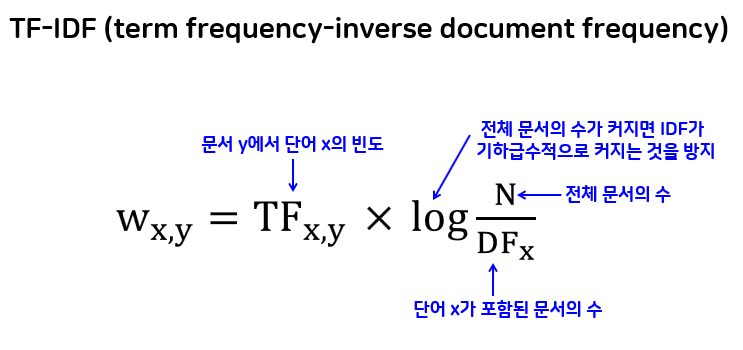

1. TF(Term Frequency) : 하나의 문서(document)에서 개별 단어들이 등장하는 빈도 수
2. DF(Document Frequency) : 하나의 단어(토큰)가 전체 말뭉치(corpus)에서 등장하는 문서(document) 수

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [93]:
sample_tf_idf = TfidfVectorizer()
sample_tf_idf.fit(sample_text)

TfidfVectorizer()

In [94]:
pd.DataFrame(
    sample_tf_idf.transform(sample_text).toarray(), # 단어사전 기반으로 tf-idf 벡터화 및 numpy 배열 변환
    columns = sample_tf_idf.get_feature_names_out() # 단어사전의 단어를 컬럼명으로 사용
)

,고프다,나는,너는,많이,먹을꺼니,먹을꺼야,무엇을,배가,아침에,어제,오늘,왔어,운동을,저녁에,치킨을,하고,했더니
0,0.000000,0.425305,0.000000,0.000000,0.000000,0.539445,0.000000,0.000000,0.000000,0.000000,0.344321,0.000000,0.000000,0.344321,0.539445,0.000000,0.000000
1,0.000000,0.000000,0.511992,0.000000,0.511992,0.000000,0.511992,0.000000,0.000000,0.000000,0.326798,0.000000,0.000000,0.326798,0.000000,0.000000,0.000000
2,0.000000,0.365594,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.463709,0.000000,0.295980,0.463709,0.365594,0.000000,0.000000,0.463709,0.000000
3,0.407265,0.000000,0.000000,0.407265,0.000000,0.000000,0.000000,0.407265,0.000000,0.407265,0.000000,0.000000,0.321093,0.259952,0.000000,0.000000,0.407265


### 혐오표현데이터 토큰화 및 수치화

In [96]:
# kiwi에서 Stopwords 객체에 들어있던 불용어 사전 확인
stopwords_set = stopwords.stopwords
stopwords_set
# set : 집합형(중복X)

{('ᆫ', 'ETM'),
 ('ᆫ', 'JX'),
 ('ᆫ다', 'EF'),
 ('ᆯ', 'ETM'),
 ('가', 'JKS'),
 ('같', 'VA'),
 ('것', 'NNB'),
 ('게', 'EC'),
 ('겠', 'EP'),
 ('고', 'EC'),
 ('고', 'JKQ'),
 ('과', 'JC'),
 ('과', 'JKB'),
 ('그', 'MM'),
 ('그', 'NP'),
 ('기', 'ETN'),
 ('까지', 'JX'),
 ('나', 'NP'),
 ('년', 'NNB'),
 ('는', 'ETM'),
 ('는', 'JX'),
 ('다', 'EC'),
 ('다', 'EF'),
 ('다고', 'EC'),
 ('다는', 'ETM'),
 ('대하', 'VV'),
 ('더', 'MAG'),
 ('던', 'ETM'),
 ('도', 'JX'),
 ('되', 'VV'),
 ('되', 'XSV'),
 ('들', 'XSN'),
 ('등', 'NNB'),
 ('따르', 'VV'),
 ('때', 'NNG'),
 ('때문', 'NNB'),
 ('라', 'EC'),
 ('라는', 'ETM'),
 ('로', 'JKB'),
 ('를', 'JKO'),
 ('만', 'JX'),
 ('만', 'NR'),
 ('말', 'NNG'),
 ('며', 'EC'),
 ('면', 'EC'),
 ('면서', 'EC'),
 ('명', 'NNB'),
 ('받', 'VV'),
 ('보', 'VV'),
 ('부터', 'JX'),
 ('사람', 'NNG'),
 ('성', 'XSN'),
 ('수', 'NNB'),
 ('아니', 'VCN'),
 ('않', 'VX'),
 ('어', 'EC'),
 ('어', 'EF'),
 ('어서', 'EC'),
 ('어야', 'EC'),
 ('없', 'VA'),
 ('었', 'EP'),
 ('에', 'JKB'),
 ('에게', 'JKB'),
 ('에서', 'JKB'),
 ('와', 'JC'),
 ('와', 'JKB'),
 ('우리', 'NP'),
 ('원', 'NNB'),


In [97]:
# set에서 단어만 추출
stopwords_list = [word for word, tag in stopwords_set]
stopwords_list

['사람',
 '말',
 '통하',
 '지',
 '우리',
 '면서',
 '이',
 '만',
 '부터',
 '다',
 '있',
 '만',
 '원',
 '중',
 '고',
 '수',
 '이',
 '도',
 '하',
 '나',
 '이',
 '다는',
 '한',
 '에서',
 'ᆫ다',
 '하',
 '그',
 '그',
 '것',
 '적',
 '지만',
 '과',
 '을',
 '겠',
 '일',
 '같',
 '등',
 '까지',
 '화',
 '으로',
 '며',
 '있',
 '없',
 '은',
 '보',
 '를',
 '면',
 '라',
 '로',
 '때문',
 '성',
 '었',
 '더',
 '어서',
 '년',
 '와',
 '과',
 '하',
 '은',
 '던',
 '따르',
 '월',
 '게',
 '고',
 '들',
 '아니',
 '있',
 '에게',
 '받',
 '되',
 '하',
 '의',
 '주',
 '어야',
 '는',
 '을',
 '위하',
 '일',
 '다고',
 '가',
 'ᆫ',
 '와',
 '제',
 '때',
 '이',
 '다',
 '기',
 '않',
 '이',
 'ᆯ',
 '는',
 '명',
 '지역',
 '라는',
 '에',
 '되',
 '대하',
 'ᆫ',
 '어',
 '어',
 '지']

In [98]:
unsmile_cv = CountVectorizer(
    stop_words = stopwords_list, # 불용어 등록
    ngram_range = (1,2),
    # n-gram 설정(유니,바이,트라이) -> 단어간의 문맥, 관계를 더 잘 반영
    max_df = 0.7,
    # 최대 등장 비율 -> 전체 문서 중 70% 이상에서 등장하는 단어는 무시하겠다는 뜻
    min_df = 10
    # 최소 등장 빈도 -> 특정 단어가 적어도 10개 이상의 문서에서 등장해야 그 단어를 고려
)

unsmile_tf_idf = TfidfVectorizer(
    stop_words = stopwords_list,
    ngram_range = (1,2),
    max_df = 0.7,
    min_df = 10
)

In [100]:
unsmile_cv.fit(konlpy_morphs_train) # 단어사전 구축
unsmile_tf_idf.fit(konlpy_morphs_train)
# test set는 모델의 성능을 평가하는데 사용되므로
# 모델이 사전에 test set의 정보를 알지 못하게 하는 것이 중요

TfidfVectorizer(max_df=0.7, min_df=10, ngram_range=(1, 2),
                stop_words=['사람', '말', '통하', '지', '우리', '면서', '이', '만', '부터',
                            '다', '있', '만', '원', '중', '고', '수', '이', '도', '하',
                            '나', '이', '다는', '한', '에서', 'ᆫ다', '하', '그', '그', '것',
                            '적', ...])

In [118]:
# CountVectorizer 단어사전 기반 변환
X_train_cv = unsmile_cv.transform(konlpy_morphs_train)
X_test_cv = unsmile_cv.transform(konlpy_morphs_test)
# tf-idf 단어사전 기반 변환
X_train_tf_idf = unsmile_tf_idf.transform(konlpy_morphs_train)
X_test_tf_idf = unsmile_tf_idf.transform(konlpy_morphs_test)

### 정답데이터 추출
- 혐오표현 : 0
- 악플&욕설 : 1
- clean : 2
> '개인 지칭'은 기존 혐오표현에 추가된 레이블 -> 제외

In [102]:
train.columns

Index(['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오',
       '악플/욕설', 'clean', '개인지칭'],
      dtype='object')

In [103]:
# 혐오표현들에 대한 라벨 병합
train['혐오표현'] = train.loc[:,"여성/가족":"기타 혐오"].sum(axis=1)
test['혐오표현'] = test.loc[:,"여성/가족":"기타 혐오"].sum(axis=1)

In [104]:
train.head()

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,혐오표현
0,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,1,0,0
1,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,0,0,1
2,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,1,0,0
3,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,1,0,0
4,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,0,0,1


In [105]:
# 새로운 데이터셋 초기화
new_train = train[['문장','혐오표현','악플/욕설','clean']]
new_test = test[['문장','혐오표현','악플/욕설','clean']]

In [106]:
# 정답 라벨링을 위한 사용자 정의함수
# 0 : 혐오표현
# 1 : 악플/욕설
# 2 : clean
def label(row):
  if row['혐오표현']>0:
    return 0
  elif row['악플/욕설'] >0 :
    return 1
  else :
    return 2

In [107]:
y_train = new_train.apply(label, axis=1)
y_test = new_test.apply(label, axis=1)

In [108]:
print(y_train.value_counts().sort_index())

0    8121
1    3143
2    3741
Name: count, dtype: int64


### 모델 학습 및 평가
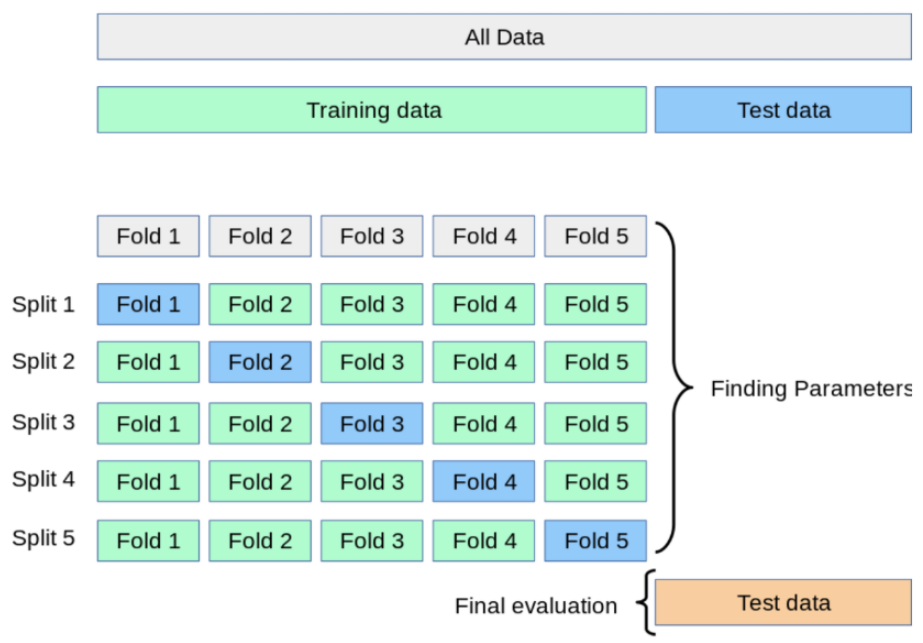

In [109]:
from sklearn.linear_model import LogisticRegression # 선형분류모델
from sklearn.model_selection import cross_val_score # 교차검증함수

In [110]:
logi = LogisticRegression(max_iter = 10000)

In [119]:
# CountVectorizer 교차검증
score_cv = cross_val_score(logi, X_train_cv, y_train, cv=5)
score_cv

array([0.64745085, 0.63712096, 0.64445185, 0.63712096, 0.64545152])

In [120]:
score_cv.mean()

np.float64(0.6423192269243586)

In [121]:
# Tf-idf 교차검증
score_tf_idf = cross_val_score(logi, X_train_tf_idf, y_train, cv=5)
score_tf_idf

array([0.6407864 , 0.63745418, 0.65111629, 0.6347884 , 0.64278574])

In [122]:
score_tf_idf.mean()

np.float64(0.6413862045984672)

### 빈도 기반 수치화의 한계와 희소표현
- 자연어 처리(NLP)에서 단어를 수치로 표현하는 가장 기본적인 방법은 cv,TF-IDF와 같은 빈도 기반 수치화
- 한계점이 존재하고, 희소 표현 문제와 밀접한 관련이 있음

#### 1. 희소 행렬 문제
- 문장을 고차원 벡터(단어 수만큼의 차원)로 표현하지만 대부분 0으로 채워짐
- 예 : 단어사전 1000개, "나는 밥을 먹었다" -> 단어 사전의 단어중 3~4개정도의 단어만 사용됨

#### 단점
- 메모리 비효율 : 대부분의 값이 0이더라도 저장 공간은 필요
- 계산 비효율 : 거리 계산, 유사도 측정 등에서 연산량 증가
---
#### 2. 단어 간 의미(의미론) 미반영
- '배고프다'와 '허기지다'는 뜻은 유사하지만 완전히 다른 벡터로 표현됨
- 단어의 의미적 유사성, 동의어/반의어 관계를 반영하지 못함
---
#### 3. 어순과 문법 정보 손실
- Bag-of-Words(BOW) 구조이기 때문에 단어의 순서가 사라짐
- "나는 너를 좋아해" <-> "너는 나를 좋아해" -> 뜻은 다르지만 유사한 벡터
---
#### 4. OOV(Out-of-Vocabulary) 문제
- 단어 사전에 없는 단어는 무시됨
- 신조어, 오타, 희귀어에 취약
- 특히 한국어는 형태소가 다양하여 더 많은 문제가 발생
---
#### 대안 : 의미와 문맥을 반영하는 임베딩
- Word2Vec, Glove : 의미기반 밀집 벡터 표현
- FastText : 부분 단어(subword)까지 학습하여 OOV 문제 완화
- BERT, GPT 등 : 문맥 기반 사전학습 언어 모델, 의미, 어순, 관계 반영 가능
---
> 빈도 기반 수치화는 단순하고 빠르지만, 의미와 문맥을 반영하지 못하고 희소성이 높다는 한계가 있음.  
> -> 현대 NLP에서는 밀집 벡터(dense vector)기반 임베딩이 주류.